## Langgraph AI Agent

In [24]:
from langgraph.graph import START, END, StateGraph
import pandas as pd

In [25]:
from typing import TypedDict, Dict, Optional

class AgentState(TypedDict):
    file_path:str
    null_details:Dict[str,int]
    nulls_exists:bool
    strategy: Optional[str]
    final_data_summary: Optional[str]

In [44]:
def check_nulls_node(state:AgentState):
    """ 
    Tool 1 : A Function Designed To Check If Null Values Exists 
    """
    path = state["file_path"]
    file = pd.read_csv(path)
    null_detail = {}
    nulls_exists = True
    cols = list(file.columns)
    for col in cols:
        null_values = file[col].isna().sum()
        null_detail[col] = int(null_values)
    if sum(null_detail.values()) == 0:
        nulls_exists = False
    return {
        "null_details": null_detail, 
        "nulls_exist": nulls_exists
    }

In [45]:
from langgraph.types import interrupt

def human_input_node(state:AgentState):
    print("Detected null Values. Please Provide Strategy: 'drop', 'fill_zero', or 'fill_mean'.")
    user_strategy = interrupt("Waiting for user input ....")
    return {"strategy":user_strategy}

In [ ]:
def resolve_nulls_node(state: AgentState):
    strategy = state.get("strategy", "").lower() 
    original_path = state.get("file_path")
    df = pd.read_csv(original_path)
    
    if "drop" in strategy:
        df = df.dropna()
    elif "zero" in strategy: 
        df = df.fillna(0)
    elif "mean" in strategy: 
        df = df.fillna(df.mean(numeric_only=True))
    else:
        print(f"Warning: Strategy '{strategy}' not recognized. No changes applied.")
        
    path_name = f"{original_path}_cleaned.csv"
    df.to_csv(path_name, index=False)
    return {"cleaned_file_path": path_name}

In [69]:
workflow = StateGraph(AgentState)

workflow.add_node("identifier",check_nulls_node)
workflow.add_node("human_review",human_input_node)
workflow.add_node("resolver",resolve_nulls_node)

workflow.set_entry_point("identifier")

workflow.add_conditional_edges(
    "identifier",
    lambda state: "human_review" if state["nulls_exist"] else END,
    {"human_review":"human_review","__end__":END}
)

workflow.add_edge("human_review","resolver")
workflow.add_edge("resolver",END)

In [70]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

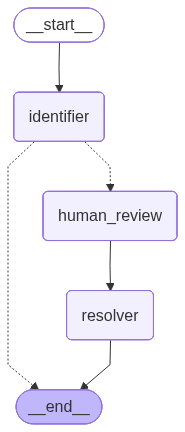

In [71]:
app

In [ ]:
# Test Case: 1
config = {"configurable": {"thread_id": "test_1"}}
app.invoke({"file_path": "file1.csv"}, config=config)

snapshot = app.get_state(config)
print(f"Agent is currently at: {snapshot.next}")


Agent is currently at: ()


In [ ]:
# Test Case: 2
config = {"configurable": {"thread_id": "test_1"}}
app.invoke({"file_path": "file2.csv"}, config=config)

# 2. Check where the graph stopped
snapshot = app.get_state(config)
print(f"Agent is currently at: {snapshot.next}")


Detected null Values. Please Provide Strategy: 'drop', 'fill_zero', or 'fill_mean'.
Agent is currently at: ('human_review',)


In [ ]:

app.update_state(config, {"strategy": "fill_zeros"}, as_node="human_review")
app.invoke(None, config=config)

{'file_path': 'file2.csv',
 'null_details': {'id': 0, 'name': 1, 'age': 2},
 'strategy': 'fill_zeros'}